In [1]:

#We build a custom multi-branch CNN with naive Inception module from scratch and train it on the Indoor Scenes CVPR 2019 dataset.

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## 1: Load image paths and labels from TrainImages.txt and TestImages.txt


In [22]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'


with open('/kaggle/input/indoor-scenes-cvpr-2019/TrainImages.txt', 'r') as f:
    trainList = [line.strip() for line in f.readlines()]

with open('/kaggle/input/indoor-scenes-cvpr-2019/TestImages.txt', 'r') as f:
    testList = [line.strip() for line in f.readlines()]

def getLabelFromPath(path):
    return path.split('/')[0]

trainFull = [(os.path.join(rootDir, x), getLabelFromPath(x)) for x in trainList]
testFull = [(os.path.join(rootDir, x), getLabelFromPath(x)) for x in testList]

trainData, valData = train_test_split(trainFull, test_size=0.2, stratify=[y for _, y in trainFull], random_state=42)


## 2: Create custom PyTorch Dataset using parsed image-label pairs


In [24]:
labelNames = sorted(set([label for _, label in trainFull]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]


## 3: Create DataLoaders for training, validation, and testing


In [25]:
batchSize = 64

trainDataset = SceneDataset(trainData, transform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testFull, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


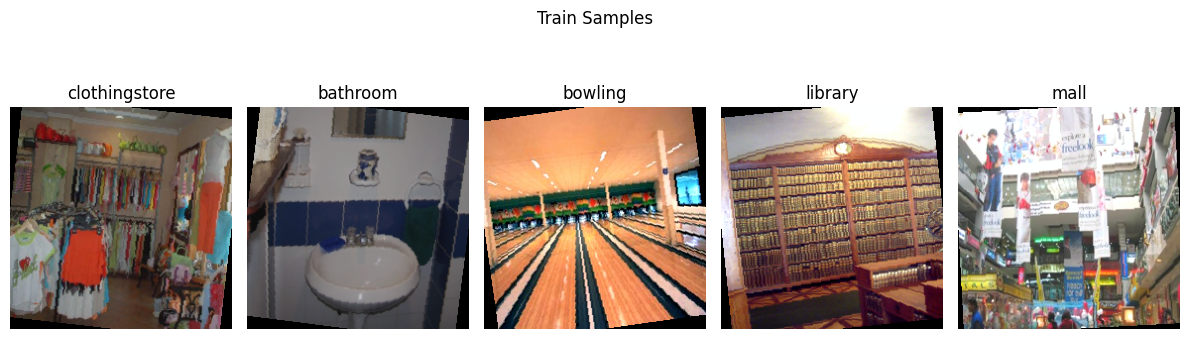

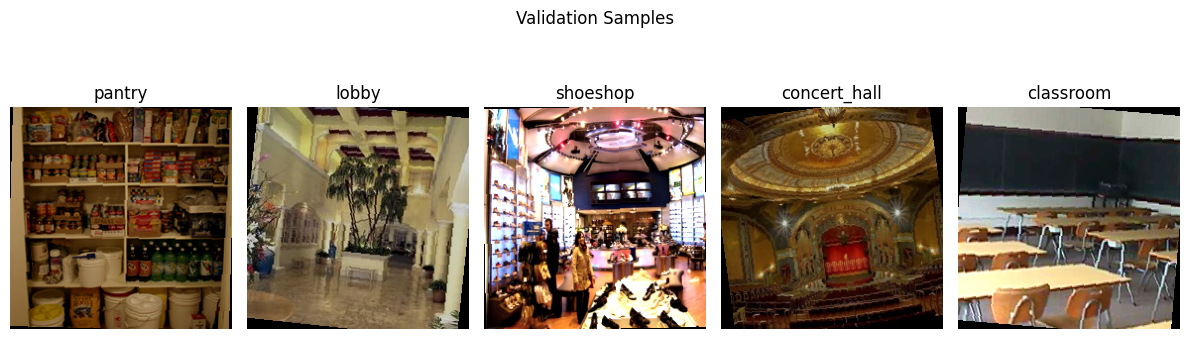

In [26]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


## 4: Define the custom multi-branch CNN using naïve Inception block


In [32]:

# Optimized Inception Block
class InceptionBlockOptimized(nn.Module):
    def __init__(self, inChannels):
        super(InceptionBlockOptimized, self).__init__()

        # 1x1 conv
        self.branch1x1 = nn.Sequential(
            nn.Conv2d(inChannels, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # 1x1 -> 3x3 conv
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(inChannels, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        # 1x1 -> 5x5 conv
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(inChannels, 16, kernel_size=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 24, kernel_size=5, padding=2),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True)
        )

        # 3x3 maxpool -> 1x1 conv
        self.branchPool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(inChannels, 24, kernel_size=1),
            nn.BatchNorm2d(24),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return torch.cat([
            self.branch1x1(x),
            self.branch3x3(x),
            self.branch5x5(x),
            self.branchPool(x)
        ], dim=1)

# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

# Final Custom Inception CNN
class CustomInceptionCNN(nn.Module):
    def __init__(self, numClasses):
        super(CustomInceptionCNN, self).__init__()

        # Initial Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Inception Stages
        self.inception1 = InceptionBlockOptimized(64)
        self.inception2 = InceptionBlockOptimized(128)
        self.inception3 = InceptionBlockOptimized(128)

        # Residual Refinement
        self.residual1 = ResidualBlock(128)
        self.residual2 = ResidualBlock(128)

        # Pool and Classifier
        self.globalAvgPool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, numClasses)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.inception3(x)
        x = self.residual1(x)
        x = self.residual2(x)
        x = self.globalAvgPool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.classifier(x)


In [34]:
from torchinfo import summary

model = CustomInceptionCNN(numClasses=67).to(device)
summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
CustomInceptionCNN                       [1, 67]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,472
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─InceptionBlockOptimized: 1-2           [1, 128, 56, 56]          --
│    └─Sequential: 2-5                   [1, 32, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 32, 56, 56]           2,080
│    │    └─BatchNorm2d: 3-2             [1, 32, 56, 56]           64
│    │    └─ReLU: 3-3                    [1, 32, 56, 56]           --
│    └─Sequential: 2-6                   [1, 48, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 32, 56, 56]           2,080
│    

## 5: Setup device, loss function, optimizer, LR scheduler, and early stopping


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomInceptionCNN(numClasses=len(classNames)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
#optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
earlyStopPatience = 5


In [36]:
def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=20, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step(valLoss)

        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f}")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModel.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [30]:
def evaluateModel(model, loader, criterion):
    model.eval()
    totalLoss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            totalLoss += loss.item()
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return totalLoss / len(loader), correct / total


In [37]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=30, earlyStopPatience=5
)


Epoch 01 | Train Acc: 0.0215 | Val Acc: 0.0429 | Train Loss: 4.2160 | Val Loss: 4.1417
Epoch 02 | Train Acc: 0.0387 | Val Acc: 0.0494 | Train Loss: 4.1332 | Val Loss: 4.0433
Epoch 03 | Train Acc: 0.0448 | Val Acc: 0.0718 | Train Loss: 4.0558 | Val Loss: 3.9403
Epoch 04 | Train Acc: 0.0555 | Val Acc: 0.0681 | Train Loss: 3.9793 | Val Loss: 3.9430
Epoch 05 | Train Acc: 0.0632 | Val Acc: 0.0914 | Train Loss: 3.9197 | Val Loss: 3.7994
Epoch 06 | Train Acc: 0.0739 | Val Acc: 0.0951 | Train Loss: 3.8731 | Val Loss: 3.7689
Epoch 07 | Train Acc: 0.0800 | Val Acc: 0.1203 | Train Loss: 3.8465 | Val Loss: 3.7184
Epoch 08 | Train Acc: 0.0965 | Val Acc: 0.1054 | Train Loss: 3.7880 | Val Loss: 3.7848
Epoch 09 | Train Acc: 0.0870 | Val Acc: 0.1315 | Train Loss: 3.7713 | Val Loss: 3.7027
Epoch 10 | Train Acc: 0.0965 | Val Acc: 0.1539 | Train Loss: 3.7458 | Val Loss: 3.6304
Epoch 11 | Train Acc: 0.1084 | Val Acc: 0.1334 | Train Loss: 3.7010 | Val Loss: 3.6605
Epoch 12 | Train Acc: 0.1182 | Val Acc: 0.1

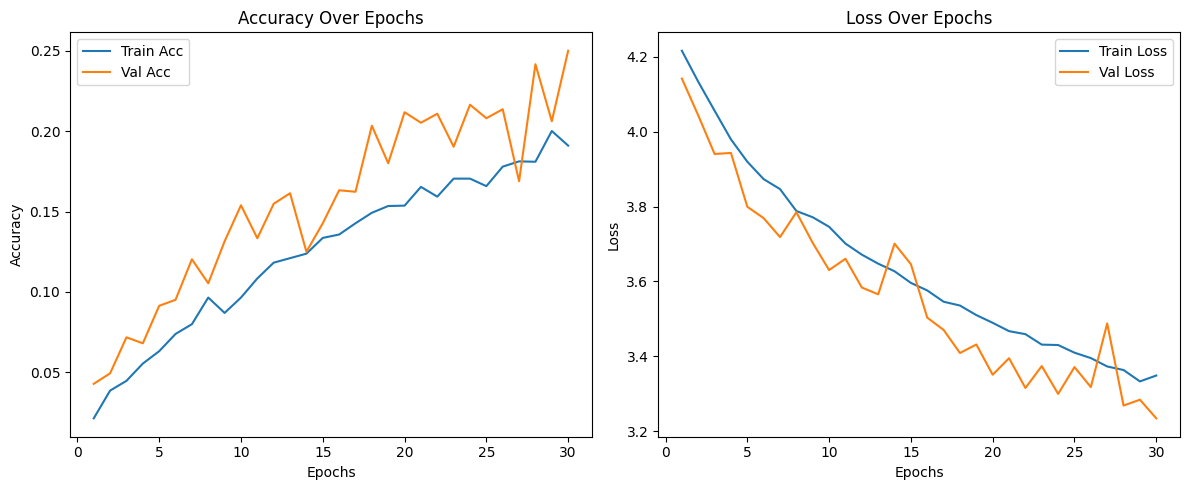

In [38]:
epochsRange = range(1, len(trainAccList)+1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochsRange, trainAccList, label='Train Acc')
plt.plot(epochsRange, valAccList, label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochsRange, trainLossList, label='Train Loss')
plt.plot(epochsRange, valLossList, label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [40]:
testLoss, testAcc = evaluateModel(model, testLoader, criterion)

print(f"Test Accuracy: {testAcc:.4f}")
print(f"Test Loss: {testLoss:.4f}")


Test Accuracy: 0.2052
Test Loss: 3.2803
